# Day 13 – LightGBM & Advanced Boosting Systems

## Objective
In this notebook, we explore **LightGBM**, a high-performance gradient boosting framework designed for speed and scalability. 

We implement LightGBM on the California Housing dataset and analyze its performance through evaluation metrics, feature importance, learning curves, and residual diagnostics.

## Dataset
California Housing Dataset

Goal: Predict median house values using housing features such as income, location, and population.

## Workflow
1. Load dataset
2. Train / Validation / Test split
3. Train LightGBM model
4. Apply early stopping
5. Evaluate performance
6. Visualize feature importance
7. Analyze residual errors

We import essential libraries for:

- Data handling → Pandas, NumPy
- Visualization → Matplotlib
- Machine Learning → Scikit-Learn
- Gradient Boosting → LightGBM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import lightgbm as lgb

## Load the California Housing Dataset

The California Housing dataset contains housing information collected from the 1990 census.

### Features
- Median Income
- House Age
- Average Rooms
- Average Bedrooms
- Population
- Average Occupancy
- Latitude
- Longitude

### Target
Median house value for districts in California.

In [2]:
data = fetch_california_housing()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

## Train / Validation / Test Split

To simulate a real machine learning workflow we divide the dataset into three parts:

- **Training Set (70%)**
  Used to train the model.

- **Validation Set (15%)**
  Used for hyperparameter tuning and early stopping.

- **Test Set (15%)**
  Used only for final model evaluation.

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

## Training the LightGBM Model

LightGBM is a gradient boosting framework developed by Microsoft.

Key characteristics:

- Histogram-based tree learning
- Leaf-wise tree growth
- Faster training than traditional gradient boosting
- Efficient handling of large datasets

### Hyperparameters Used

- **n_estimators** → Number of boosting trees
- **learning_rate** → Step size for gradient updates
- **num_leaves** → Maximum leaves per tree
- **max_depth** → Maximum tree depth

In [8]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(0)   # disables logs
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 8
[LightGBM] [Info] Start training from score 2.069240
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	training's rmse: 0.244244	training's l2: 0.0596553	valid_1's rmse: 0.447745	valid_1's l2: 0.200475


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Evaluation

To measure performance we use:

- **RMSE (Root Mean Squared Error)**  
  Measures prediction error magnitude.

- **R² Score**  
  Measures proportion of variance explained by the model.

A lower RMSE and higher R² indicate better predictive performance.

In [9]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.4221593647767499
R2: 0.8652218674158321


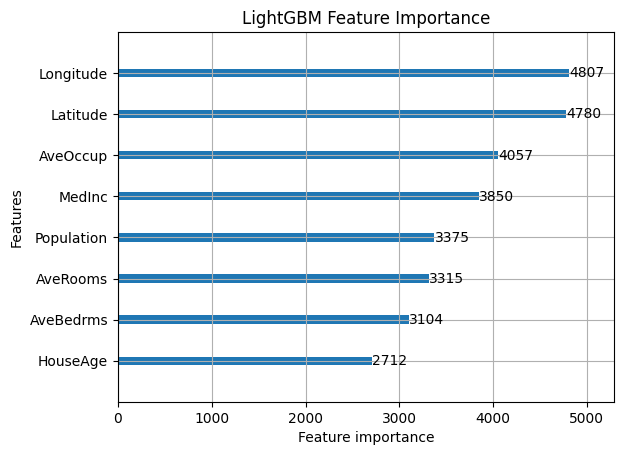

In [10]:
lgb.plot_importance(model, max_num_features=10)
plt.title("LightGBM Feature Importance")
plt.show()

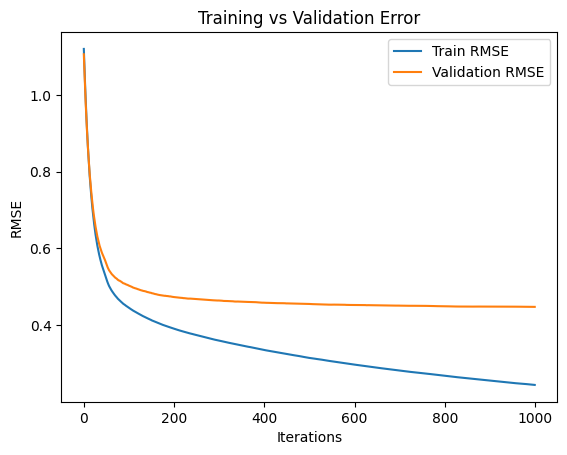

In [11]:
results = model.evals_result_

plt.plot(results['training']['rmse'], label='Train RMSE')
plt.plot(results['valid_1']['rmse'], label='Validation RMSE')

plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.title("Training vs Validation Error")
plt.legend()
plt.show()

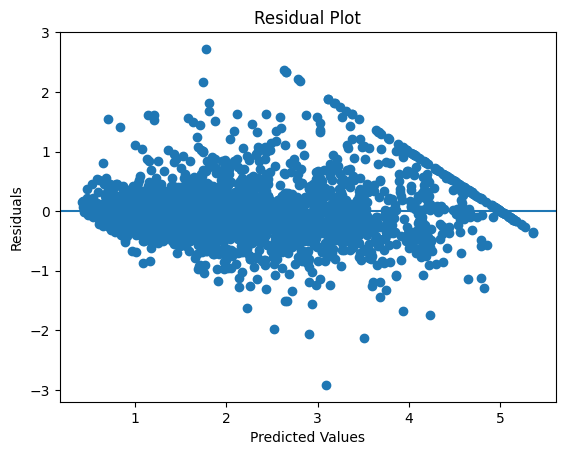

In [12]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()